# Code Implementation for the project: **A STACKED ENSEMBLE APPROACH TO CREDIT RISK ASSESSMENT AND LOAN APPROVAL **

## Data Acquisition and Relational Integration

In [3]:
import pandas as pd

# Step 1: Load the Excel files into pandas DataFrames
print("Loading datasets...")
df1 = pd.read_excel('credit_risk_file_1.xlsx')
df2 = pd.read_excel('credit_risk_file_2.xlsx')

print(f"File 1 Shape: {df1.shape} | File 2 Shape: {df2.shape}")

# Step 2: Perform a deterministic Inner Join on the primary key 'PROSPECTID'
print("\nMerging datasets on 'PROSPECTID'...")
master_df = pd.merge(df1, df2, on='PROSPECTID', how='inner')

# Step 3: Verify the shape of the integrated master dataframe
print(f"Master Dataset Shape after Inner Join: {master_df.shape}")

# Step 4: Isolate and drop the non-predictive key 'PROSPECTID' 
# We keep it in a separate variable just in case, then drop it from our training matrix
prospect_ids = master_df['PROSPECTID']
master_df = master_df.drop(columns=['PROSPECTID'])

print(f"Final Master Dataset Shape for Machine Learning: {master_df.shape}")

# Step 5: Check the target column presence and row/column overview
print("\nTarget Column Distribution (Raw):")
print(master_df['Approved_Flag'].value_counts())

# Display the first few rows to confirm successful integration
master_df.head()

Loading datasets...
File 1 Shape: (51336, 26) | File 2 Shape: (51336, 62)

Merging datasets on 'PROSPECTID'...
Master Dataset Shape after Inner Join: (51336, 87)
Final Master Dataset Shape for Machine Learning: (51336, 86)

Target Column Distribution (Raw):
Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64


,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,5,4,1,0,0,0.000,0.0,0.200,0.800,0,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,1,0,1,0,0,0.000,0.0,1.000,0.000,1,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,8,0,8,1,0,0.125,0.0,1.000,0.000,2,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,1,0,1,1,0,1.000,0.0,1.000,0.000,1,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,3,2,1,0,0,0.000,0.0,0.333,0.667,0,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


## Exploratory Data Analysis (EDA) and Diagnostics

--- Starting Phase 2: EDA and Multicollinearity Diagnostics ---
Identified 80 numerical features for collinearity testing.


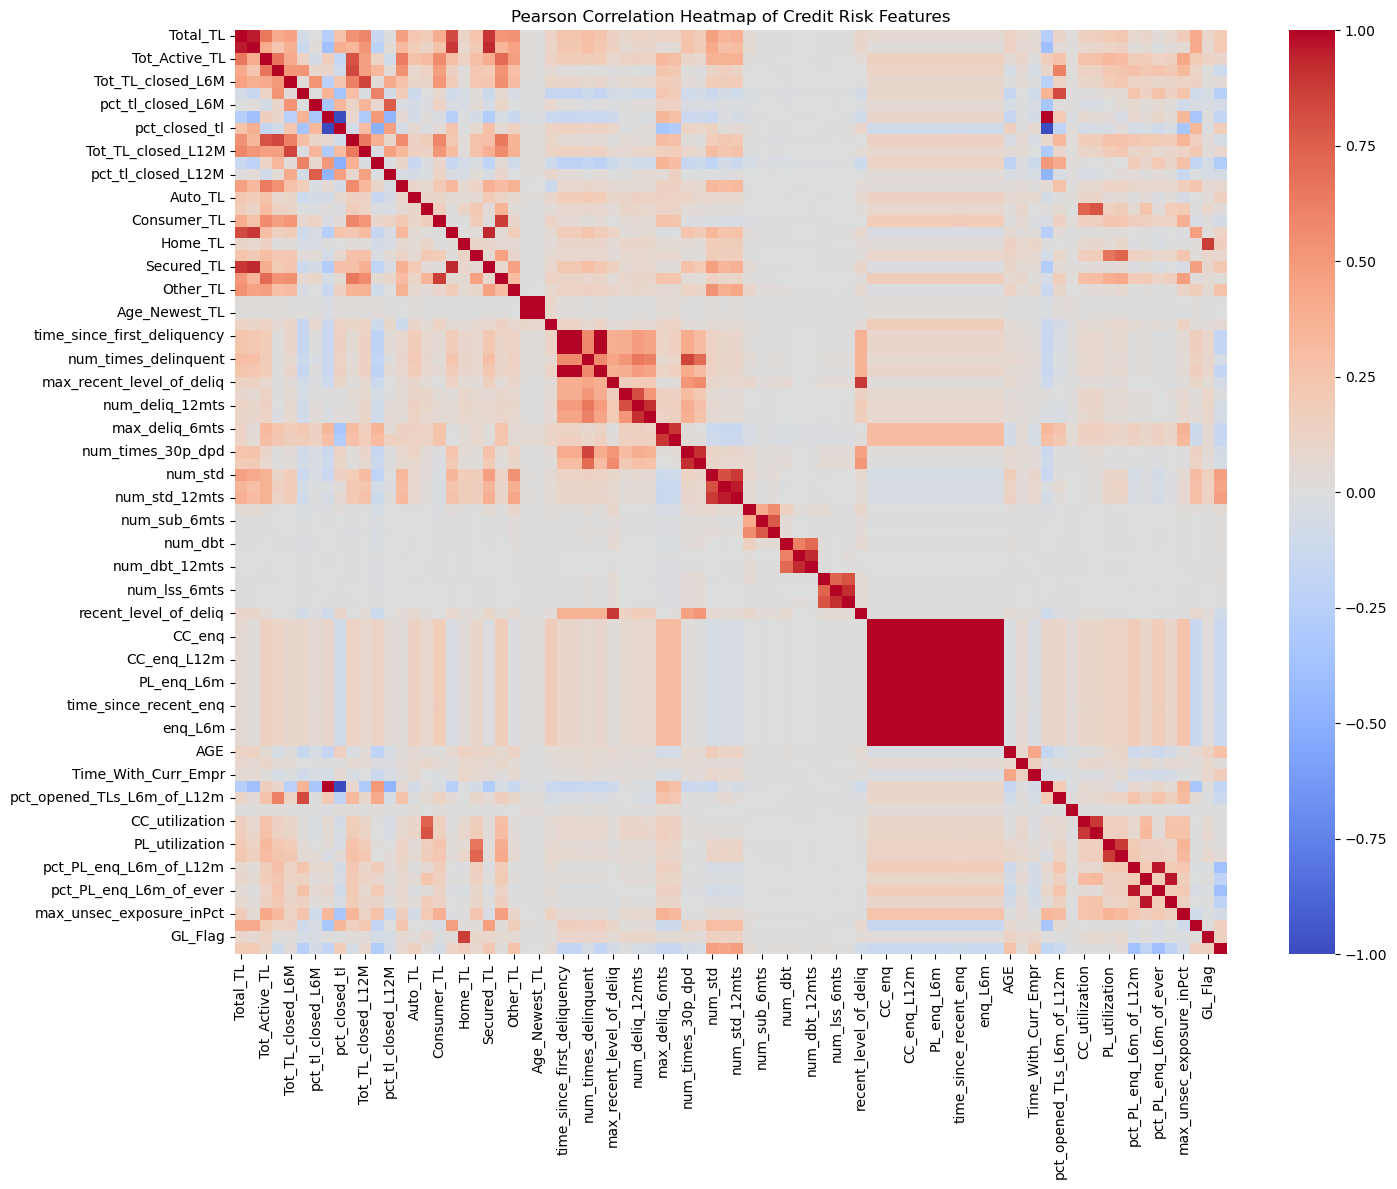


Calculating Variance Inflation Factors (VIF)... (This may take a minute)


C:\Users\AtomDev\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Found 42 features with VIF > 10 (High Multicollinearity):
                     feature          VIF
                    Total_TL          inf
                     Home_TL          inf
      pct_of_active_TLs_ever          inf
           num_deliq_6_12mts          inf
               Tot_Closed_TL          inf
              num_deliq_6mts          inf
                    Other_TL          inf
                Unsecured_TL          inf
                  Secured_TL          inf
                       PL_TL          inf
             num_deliq_12mts          inf
                     Gold_TL          inf
                 Consumer_TL          inf
                       CC_TL          inf
                     Auto_TL          inf
               Tot_Active_TL          inf
               pct_active_tl          inf
                 CC_enq_L12m 1.320911e+10
                  CC_enq_L6m 1.150800e+10
                  PL_enq_L6m 7.155118e+09
                 PL_enq_L12m 6.433755e+09
                 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("--- Starting Phase 2: EDA and Multicollinearity Diagnostics ---")

# Step 1: Separate numerical columns for correlation and VIF analysis
# We exclude categorical columns and the target column for math stability
numeric_cols = master_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Identified {len(numeric_cols)} numerical features for collinearity testing.")

# Step 2: Generate Pearson Correlation Matrix
corr_matrix = master_df[numeric_cols].corr()

# Plot a heatmap of the correlation matrix to visually inspect patches of collinearity
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Pearson Correlation Heatmap of Credit Risk Features')
plt.show()

# Step 3: Compute Variance Inflation Factor (VIF)
# We add a constant column as required by statsmodels VIF framework
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_cols

print("\nCalculating Variance Inflation Factors (VIF)... (This may take a minute)")
# Dropping any remaining rows with missing values temporarily just for the VIF math calculation
vif_df_clean = master_df[numeric_cols].dropna()

vif_data["VIF"] = [variance_inflation_factor(vif_df_clean.values, i) for i in range(vif_df_clean.shape[1])]

# Step 4: Filter and display features with extreme multicollinearity (VIF > 10)
high_vif = vif_data[vif_data["VIF"] > 10].sort_values(by="VIF", ascending=False)
print(f"\nFound {len(high_vif)} features with VIF > 10 (High Multicollinearity):")
print(high_vif.to_string(index=False))

### Automated Multicollinearity Pruning

In [9]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("--- Refining Phase 2: Running Recursive VIF Pruning ---")

# 1. Isolate the numeric features matrix (excluding target column)
numeric_df = master_df.select_dtypes(include=[np.number]).dropna().copy()

# Add a constant column for stable VIF calculation intercept
numeric_df['intercept'] = 1.0

# 2. Loop to iteratively drop features with VIF > 10
thresh = 10.0
while True:
    columns = numeric_df.columns.tolist()
    # Skip checking the helper intercept column
    feature_cols = [c for c in columns if c != 'intercept']
    
    if len(feature_cols) <= 1:
        break
        
    # Calculate VIFs for current feature subset
    vifs = [variance_inflation_factor(numeric_df.values, columns.index(c)) for c in feature_cols]
    max_vif = max(vifs)
    
    if max_vif > thresh:
        # Find the feature column with the maximum VIF value
        max_idx = vifs.index(max_vif)
        feature_to_drop = feature_cols[max_idx]
        print(f"Dropping redundant feature: '{feature_to_drop}' (VIF = {max_vif:.2f})")
        numeric_df = numeric_df.drop(columns=[feature_to_drop])
    else:
        break

# Remove our temporary calculation intercept column
if 'intercept' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['intercept'])

# 3. Reconstruct master_df with only the non-collinear numeric features + categorical/target features
dropped_numeric_features = [c for c in master_df.select_dtypes(include=[np.number]).columns if c not in numeric_df.columns]
master_df = master_df.drop(columns=dropped_numeric_features)

print("\n--- Pruning Complete ---")
print(f"Successfully removed {len(dropped_numeric_features)} collinear features.")
print(f"Remaining Final Master Dataset Shape: {master_df.shape}")

--- Refining Phase 2: Running Recursive VIF Pruning ---


C:\Users\AtomDev\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping redundant feature: 'Total_TL' (VIF = inf)


C:\Users\AtomDev\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping redundant feature: 'Tot_Closed_TL' (VIF = inf)


...

Dropping redundant feature: 'pct_closed_tl' (VIF = inf)


C:\Users\AtomDev\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping redundant feature: 'Auto_TL' (VIF = inf)


C:\Users\AtomDev\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping redundant feature: 'num_deliq_6mts' (VIF = inf)
Dropping redundant feature: 'CC_enq_L12m' (VIF = 13209109427.35)
Dropping redundant feature: 'PL_enq_L6m' (VIF = 7150676314.01)
Dropping redundant feature: 'CC_enq_L6m' (VIF = 3745363828.97)
Dropping redundant feature: 'PL_enq_L12m' (VIF = 3108875633.14)
Dropping redundant feature: 'enq_L6m' (VIF = 1903848227.90)
Dropping redundant feature: 'enq_L3m' (VIF = 827831284.85)
Dropping redundant feature: 'PL_enq' (VIF = 520353070.54)
Dropping redundant feature: 'enq_L12m' (VIF = 428642858.06)
Dropping redundant feature: 'time_since_first_deliquency' (VIF = 179220144.68)
Dropping redundant feature: 'tot_enq' (VIF = 106664281.84)
Dropping redundant feature: 'max_delinquency_level' (VIF = 2012089.03)
Dropping redundant feature: 'Age_Oldest_TL' (VIF = 15640.46)
Dropping redundant feature: 'CC_enq' (VIF = 8119.08)
Dropping redundant feature: 'Secured_TL' (VIF = 68.34)
Dropping redundant feature: 'num_std_12mts' (VIF = 21.67)
Dropping redund

### Structural Preview & Visualizing Class Imbalance

--- Phase 2: Structural Summary and Target Exploration ---
Total Categorical Features remaining: 6
Total Numerical Features remaining: 54

Categorical Features found: ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']


C:\Users\AtomDev\AppData\Local\Temp\ipykernel_30504\698740770.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Approved_Flag', data=master_df, order=class_order, palette='viridis')


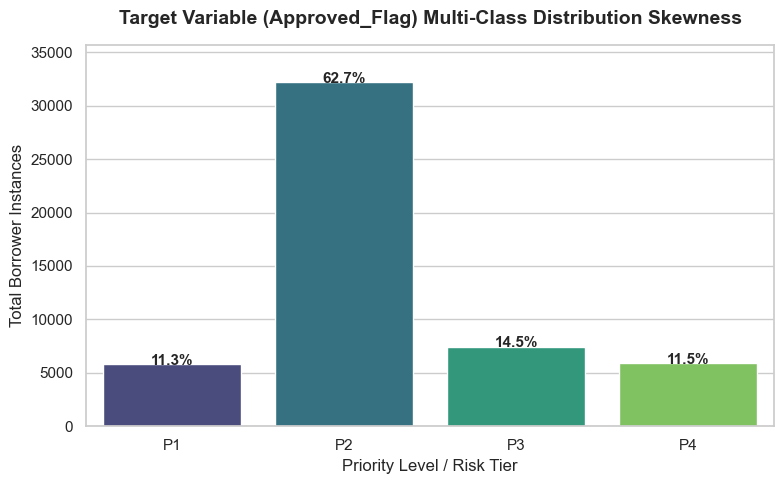

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Phase 2: Structural Summary and Target Exploration ---")

# Step 1: Preview current data types to confirm the feature split
cat_cols = master_df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = master_df.select_dtypes(include=['number']).columns.tolist()

print(f"Total Categorical Features remaining: {len(cat_cols)}")
print(f"Total Numerical Features remaining: {len(num_cols)}")
print("\nCategorical Features found:", cat_cols)

# Step 2: Set up the plotting environment for the Class Distribution Chart
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Create a count plot for the target variable 'Approved_Flag'
# Ordered manually so the progression from P1 to P4 is clear
class_order = ['P1', 'P2', 'P3', 'P4']
ax = sns.countplot(x='Approved_Flag', data=master_df, order=class_order, palette='viridis')

# Annotate each bar with its exact percentage representation
total_records = len(master_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_records:.1f}%'
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = p.get_height() + 300  # Offset text slightly above the bar apex
    ax.annotate(percentage, (x_pos, y_pos), ha='center', va='center', weight='bold', size=11)

plt.title('Target Variable (Approved_Flag) Multi-Class Distribution Skewness', fontsize=14, weight='bold', pad=15)
plt.xlabel('Priority Level / Risk Tier', fontsize=12)
plt.ylabel('Total Borrower Instances', fontsize=12)
plt.ylim(0, master_df['Approved_Flag'].value_counts().max() + 3500)  # Dynamic headroom spacing

# Show the chart
plt.tight_layout()
plt.show()

## Advanced Data Preprocessing and Target Encoding!

### Target Ordinal Encoding

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("--- Starting Phase 3: Advanced Data Preprocessing and Target Encoding ---")

# Copy dataframe to preserve the original structural state
processed_df = master_df.copy()

# ----------------------------------------------------
# STEP 1: TARGET ORDINAL ENCODING
# ----------------------------------------------------
target_mapping = {'P1': 0, 'P2': 1, 'P3': 2, 'P4': 3}
processed_df['Approved_Flag'] = processed_df['Approved_Flag'].map(target_mapping)
print("✔ Successfully encoded target variable 'Approved_Flag' to numeric indices [0, 1, 2, 3].")

--- Starting Phase 3: Advanced Data Preprocessing and Target Encoding ---
✔ Successfully encoded target variable 'Approved_Flag' to numeric indices [0, 1, 2, 3].


In [20]:
# ----------------------------------------------------
# STEP 2: SEPARATE FEATURES AND IDENTIFY ROLES
# ----------------------------------------------------
y = processed_df['Approved_Flag']
X = processed_df.drop(columns=['Approved_Flag'])

# Classify remaining column types
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Identify binary vs nominal flags among categorical columns
binary_cat_cols = [col for col in cat_cols if X[col].nunique() <= 2]
nominal_cat_cols = [col for col in cat_cols if X[col].nunique() > 2]

In [22]:
# ----------------------------------------------------
# STEP 3: MISSING VALUE IMPUTATION & OUTLIER CAPPING
# ----------------------------------------------------
for col in num_cols:
    # 3a. Impute missing values with column median
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())
    
    # 3b. Outlier Capping via IQR to protect models from heavy mathematical distortion
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X[col] = np.clip(X[col], lower_bound, upper_bound)

for col in cat_cols:
    # Impute missing strings with column mode
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].mode()[0])

print("✔ Completed missing value imputation and robust outlier IQR capping.")

✔ Completed missing value imputation and robust outlier IQR capping.


In [24]:
# ----------------------------------------------------
# STEP 4: CATEGORICAL MATRIX ENCODING
# ----------------------------------------------------
# Label Encoding for binary flags
le = LabelEncoder()
for col in binary_cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# One-Hot Encoding for multi-class nominal indicators
if len(nominal_cat_cols) > 0:
    X = pd.get_dummies(X, columns=nominal_cat_cols, drop_first=True, dtype=int)

print("✔ Executed nominal One-Hot Encoding and binary Label Encoding transformations.")

✔ Executed nominal One-Hot Encoding and binary Label Encoding transformations.


In [26]:
# ----------------------------------------------------
# STEP 5: CONTINUOUS VARIABLE STANDARDIZATION
# ----------------------------------------------------
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
print("✔ Continuous variables standardized to zero mean and unit variance.")

✔ Continuous variables standardized to zero mean and unit variance.


In [28]:
# ----------------------------------------------------
# STEP 6: VERIFY FINAL DATA COMPOSITION
# ----------------------------------------------------
print("\n--- Phase 3 Matrix Transformations Complete ---")
print(f"Final Preprocessed Feature Matrix (X) Shape: {X.shape}")
print(f"Final Target Array (y) Shape: {y.shape}")
print("Ready for partitioning and algorithmic balancing.")


--- Phase 3 Matrix Transformations Complete ---
Final Preprocessed Feature Matrix (X) Shape: (51336, 72)
Final Target Array (y) Shape: (51336,)
Ready for partitioning and algorithmic balancing.


## Data Partitioning and Class Imbalance Resolution

In [31]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

print("--- Starting Phase 4: Data Partitioning and Class Imbalance Resolution ---")

# Step 1: Execute a Stratified 70/30 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

print(f"Initial Training Target Distribution: {Counter(y_train)}")
print(f"Initial Testing Target Distribution:  {Counter(y_test)}")

--- Starting Phase 4: Data Partitioning and Class Imbalance Resolution ---
Initial Training Target Distribution: Counter({1: 22539, 2: 5216, 3: 4118, 0: 4062})
Initial Testing Target Distribution:  Counter({1: 9660, 2: 2236, 3: 1764, 0: 1741})


In [33]:
# Step 2: Apply SMOTE exclusively to the Training Partition
print("\nApplying SMOTE to balance multi-class training distributions...")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\n--- Algorithmic Balancing Complete ---")
print(f"Balanced Training Feature Matrix Shape: {X_train_bal.shape}")
print(f"Balanced Training Target Vector Shape:  {y_train_bal.shape}")
print(f"Final Balanced Training Distribution:   {Counter(y_train_bal)}")
print(f"Untouched Testing Target Distribution:  {Counter(y_test)}")


Applying SMOTE to balance multi-class training distributions...

--- Algorithmic Balancing Complete ---
Balanced Training Feature Matrix Shape: (90156, 72)
Balanced Training Target Vector Shape:  (90156,)
Final Balanced Training Distribution:   Counter({1: 22539, 0: 22539, 2: 22539, 3: 22539})
Untouched Testing Target Distribution:  Counter({1: 9660, 2: 2236, 3: 1764, 0: 1741})


### Previewing dataset distribution before and after applying SMOTE

--- Visualizing SMOTE Class Balancing Results ---


C:\Users\AtomDev\AppData\Local\Temp\ipykernel_30504\3036000849.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Priority_Level', data=df_before, order=class_order, ax=axes[0], palette='plasma')
C:\Users\AtomDev\AppData\Local\Temp\ipykernel_30504\3036000849.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Priority_Level', data=df_after, order=class_order, ax=axes[1], palette='viridis')


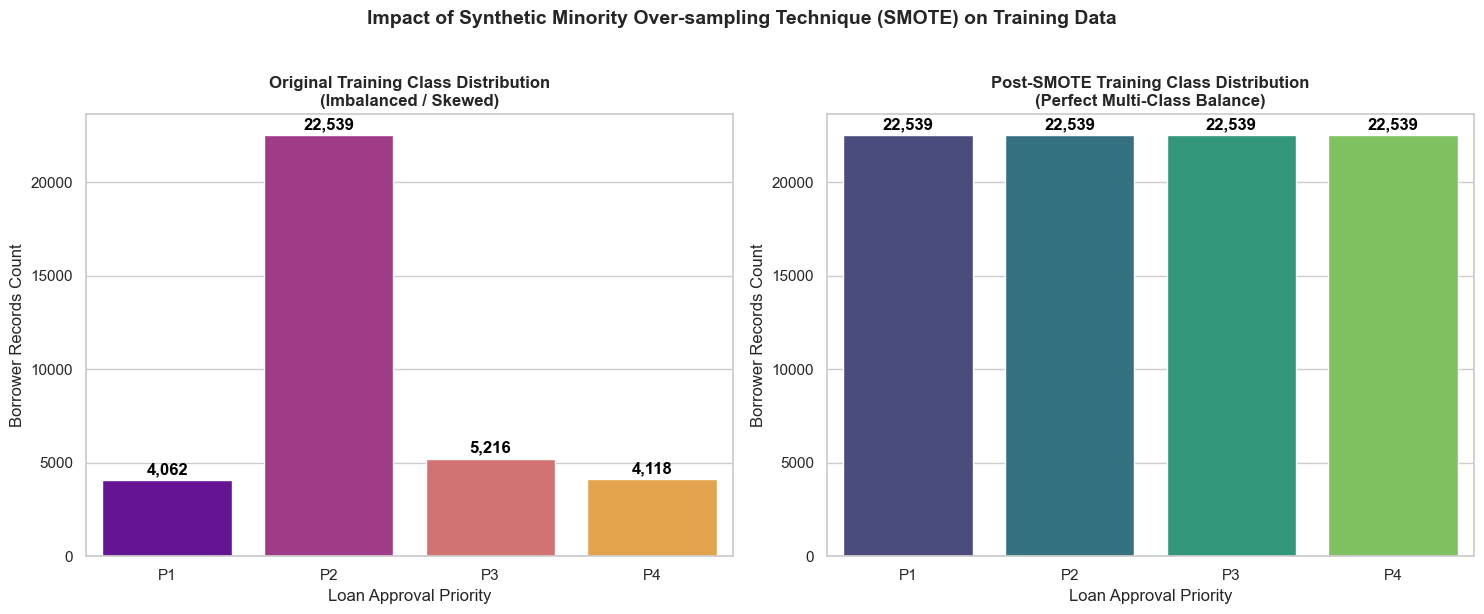

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- Visualizing SMOTE Class Balancing Results ---")

# 1. Create DataFrames for plotting ease
df_before = pd.DataFrame({'Priority_Level': y_train.map({0:'P1', 1:'P2', 2:'P3', 3:'P4'})})
df_after = pd.DataFrame({'Priority_Level': y_train_bal.map({0:'P1', 1:'P2', 2:'P3', 3:'P4'})})

# 2. Set up a side-by-side subplot canvas
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
sns.set_theme(style="whitegrid")
class_order = ['P1', 'P2', 'P3', 'P4']

# Plot 1: Imbalanced Training Set (Before SMOTE)
sns.countplot(x='Priority_Level', data=df_before, order=class_order, ax=axes[0], palette='plasma')
axes[0].set_title('Original Training Class Distribution\n(Imbalanced / Skewed)', fontsize=12, weight='bold')
axes[0].set_xlabel('Loan Approval Priority')
axes[0].set_ylabel('Borrower Records Count')

# Annotate values on Plot 1
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height() + 200),
                ha='center', va='center', weight='bold', color='black', xytext=(0, 5), textcoords='offset points')

# Plot 2: Balanced Training Set (After SMOTE)
sns.countplot(x='Priority_Level', data=df_after, order=class_order, ax=axes[1], palette='viridis')
axes[1].set_title('Post-SMOTE Training Class Distribution\n(Perfect Multi-Class Balance)', fontsize=12, weight='bold')
axes[1].set_xlabel('Loan Approval Priority')
axes[1].set_ylabel('Borrower Records Count')

# Annotate values on Plot 2
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height() + 200),
                ha='center', va='center', weight='bold', color='black', xytext=(0, 5), textcoords='offset points')

# Clean layout presentation
plt.suptitle('Impact of Synthetic Minority Over-sampling Technique (SMOTE) on Training Data', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Feature Selection and Dimensionality Reduction

In [40]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

print("--- Starting Phase 5: Feature Selection and Dimensionality Reduction ---")

# Step 1: Compute Mutual Information Scores across the balanced training data
print("Calculating Mutual Information scores... (This may take a minute due to sample size)")
mi_scores = mutual_info_classif(X_train_bal, y_train_bal, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_bal.columns).sort_values(ascending=False)

# Step 2: Fit a Random Forest model to calculate structural feature importances
print("Fitting Random Forest for Gini Impurity Importance estimation...")
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_bal, y_train_bal)
rf_series = pd.Series(rf_selector.feature_importances_, index=X_train_bal.columns).sort_values(ascending=False)

# Step 3: Normalize and average the rankings to form a Robust Hybrid Score
mi_rank = mi_series.rank(ascending=True)
rf_rank = rf_series.rank(ascending=True)
combined_rank = (mi_rank + rf_rank) / 2
top_features = combined_rank.sort_values(ascending=False).head(35).index.tolist()

print(f"\n✔ Feature selection complete. Selected the Top 35 most predictive features.")

# Step 4: Prune feature matrices to contain only selected top-tier features
X_train_selected = X_train_bal[top_features]
X_test_selected = X_test[top_features]

print(f"Optimized Training Feature Matrix Shape: {X_train_selected.shape}")
print(f"Optimized Testing Feature Matrix Shape:  {X_test_selected.shape}")

# Display the top 15 features for verification
print("\nTop 15 Most Informative Selected Features:")
print(combined_rank.sort_values(ascending=False).head(15))

--- Starting Phase 5: Feature Selection and Dimensionality Reduction ---
Calculating Mutual Information scores... (This may take a minute due to sample size)
Fitting Random Forest for Gini Impurity Importance estimation...

✔ Feature selection complete. Selected the Top 35 most predictive features.
Optimized Training Feature Matrix Shape: (90156, 35)
Optimized Testing Feature Matrix Shape:  (15401, 35)

Top 15 Most Informative Selected Features:
Credit_Score                    72.0
time_since_recent_enq           71.0
AGE                             69.0
num_std                         69.0
pct_tl_open_L12M                67.0
num_std_6mts                    65.0
pct_of_active_TLs_ever          64.5
Time_With_Curr_Empr             64.5
Age_Newest_TL                   63.5
NETMONTHLYINCOME                62.5
time_since_recent_deliquency    61.5
time_since_recent_payment       61.5
pct_tl_open_L6M                 61.0
Other_TL                        60.0
pct_currentBal_all_TL           

### Visualise feature selection results

--- Visualizing Feature Selection Results ---


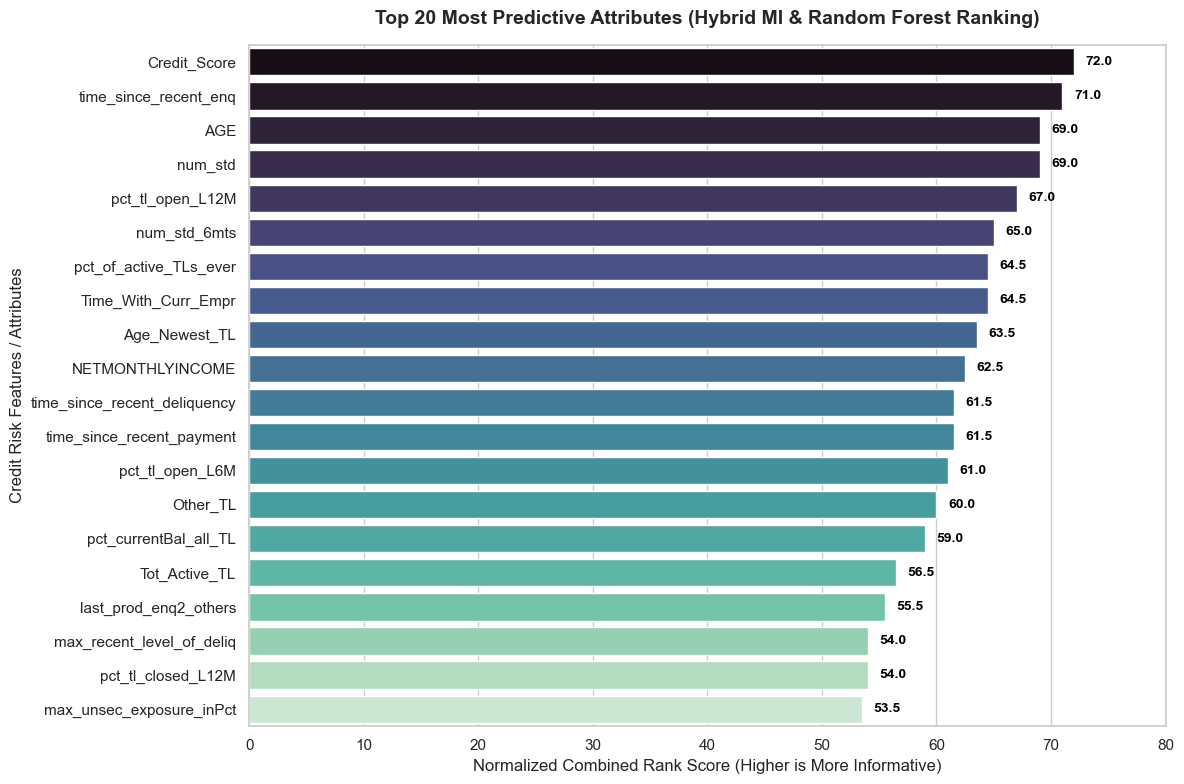

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Visualizing Feature Selection Results ---")

# 1. Isolate the top 20 features and their scores for clean plotting
top_20_features = combined_rank.sort_values(ascending=False).head(20)

# 2. Initialize the plotting canvas
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Create the horizontal bar plot
ax = sns.barplot(
    x=top_20_features.values, 
    y=top_20_features.index, 
    palette='mako',
    hue=top_20_features.index,
    legend=False
)

# 3. Add value labels to the end of each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}', 
        (width + 1.0, p.get_y() + p.get_height() / 2.),
        ha='left', 
        va='center', 
        weight='bold', 
        size=10, 
        color='black'
    )

# 4. Final layout annotations
plt.title('Top 20 Most Predictive Attributes (Hybrid MI & Random Forest Ranking)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Normalized Combined Rank Score (Higher is More Informative)', fontsize=12)
plt.ylabel('Credit Risk Features / Attributes', fontsize=12)
plt.xlim(0, 80)  # Add dynamic headroom for text space

plt.tight_layout()
plt.show()

## Stacking Ensemble Model Development (Level-0 Base Learners)

In [50]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import lightgbm as lgb

print("--- Starting Phase 6: Level-0 Base Learner Training & OOF Generation ---")

# Step 1: Initialize the Stratified K-Fold split structure (5-fold cross-validation)
cv_structure = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 2: Define the three diverse base learners
model_lr  = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42, n_jobs=-1)
model_rf  = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
model_lgb = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, objective='multiclass', num_class=4, random_state=42, verbose=-1, n_jobs=-1)

# Step 3: Generate Out-of-Fold (OOF) probability predictions for the training data
print("Generating OOF Predictions for Model 1: Logistic Regression...")
oof_pred_lr = cross_val_predict(model_lr, X_train_selected, y_train_bal, cv=cv_structure, method='predict_proba', n_jobs=-1)

print("Generating OOF Predictions for Model 2: Random Forest (Bagging)...")
oof_pred_rf = cross_val_predict(model_rf, X_train_selected, y_train_bal, cv=cv_structure, method='predict_proba', n_jobs=-1)

print("Generating OOF Predictions for Model 3: LightGBM (Boosting)...")
oof_pred_lgb = cross_val_predict(model_lgb, X_train_selected, y_train_bal, cv=cv_structure, method='predict_proba', n_jobs=-1)

# Step 4: Construct the Meta-Feature Matrix for Level-1 training
# Since there are 4 classes, each model outputs 4 columns of probabilities, totaling 12 meta-features
X_meta_train = np.hstack([oof_pred_lr, oof_pred_rf, oof_pred_lgb])

# Step 5: Fit the final baseline versions of the models onto the entire training set to prepare for testing later
print("\nFitting final individual base learner iterations on the full balanced dataset...")
model_lr.fit(X_train_selected, y_train_bal)
model_rf.fit(X_train_selected, y_train_bal)
model_lgb.fit(X_train_selected, y_train_bal)

# Step 6: Generate companion prediction features for the holdout test matrix
test_pred_lr = model_lr.predict_proba(X_test_selected)
test_pred_rf = model_rf.predict_proba(X_test_selected)
test_pred_lgb = model_lgb.predict_proba(X_test_selected)
X_meta_test = np.hstack([test_pred_lr, test_pred_rf, test_pred_lgb])

print("\n--- Level-0 Compilation Complete ---")
print(f"Meta-Train Feature Matrix Shape: {X_meta_train.shape} (90156 samples x 12 probability vectors)")
print(f"Meta-Test Feature Matrix Shape:  {X_meta_test.shape} (15401 samples x 12 probability vectors)")

--- Starting Phase 6: Level-0 Base Learner Training & OOF Generation ---
Generating OOF Predictions for Model 1: Logistic Regression...
Generating OOF Predictions for Model 2: Random Forest (Bagging)...
Generating OOF Predictions for Model 3: LightGBM (Boosting)...

Fitting final individual base learner iterations on the full balanced dataset...


C:\Users\AtomDev\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Level-0 Compilation Complete ---
Meta-Train Feature Matrix Shape: (90156, 12) (90156 samples x 12 probability vectors)
Meta-Test Feature Matrix Shape:  (15401, 12) (15401 samples x 12 probability vectors)


## Level-1 Meta-Learner Stacking Integration

In [53]:
import xgboost as xgb
print("--- Starting Phase 6: Level-1 Meta-Learner Training ---")

# Step 1: Initialize the Meta-Learner (XGBoost configured for multi-class classification)
meta_learner = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=4,
    random_state=42,
    n_jobs=-1
)

# Step 2: Train the Meta-Learner on the Out-of-Fold base predictions
print("Training Level-1 Meta-Learner (XGBoost) on Level-0 prediction matrices...")
meta_learner.fit(X_meta_train, y_train_bal)

# Step 3: Generate the final ensemble predictions for the holdout test data
ensemble_preds = meta_learner.predict(X_meta_test)
ensemble_probs = meta_learner.predict_proba(X_meta_test)

print("\n--- Meta-Learner Training and Prediction Complete ---")
print("The full Stacking Ensemble pipeline is now completely built.")
print("Proceeding next to Phase 7 for the master comparative evaluation framework.")

--- Starting Phase 6: Level-1 Meta-Learner Training ---
Training Level-1 Meta-Learner (XGBoost) on Level-0 prediction matrices...

--- Meta-Learner Training and Prediction Complete ---
The full Stacking Ensemble pipeline is now completely built.
Proceeding next to Phase 7 for the master comparative evaluation framework.


## Multi-Class Evaluation and Comparative Framework

--- Starting Phase 7: Multi-Class Evaluation Framework ---

=== MASTER PERFORMANCE COMPARISON (OVERALL) ===
 Model Architecture  Accuracy  Macro Precision  Macro Recall  Macro F1-Score
Logistic Regression    0.8966           0.8863        0.9352          0.9023
      Random Forest    0.9857           0.9886        0.9730          0.9805
           LightGBM    0.9946           0.9900        0.9888          0.9894
   Stacked Ensemble    0.9938           0.9879        0.9879          0.9879

=== PER-CLASS F1-SCORE BREAKDOWN ===
                     P1 (Low Risk)  P2 (Med-Low)  P3 (Med-High)  P4 (High Risk)
Logistic Regression         0.9714        0.9157         0.7228          0.9994
Random Forest               0.9684        0.9912         0.9631          0.9994
LightGBM                    0.9762        1.0000         0.9816          0.9997
Stacked Ensemble            0.9735        0.9999         0.9786          0.9994


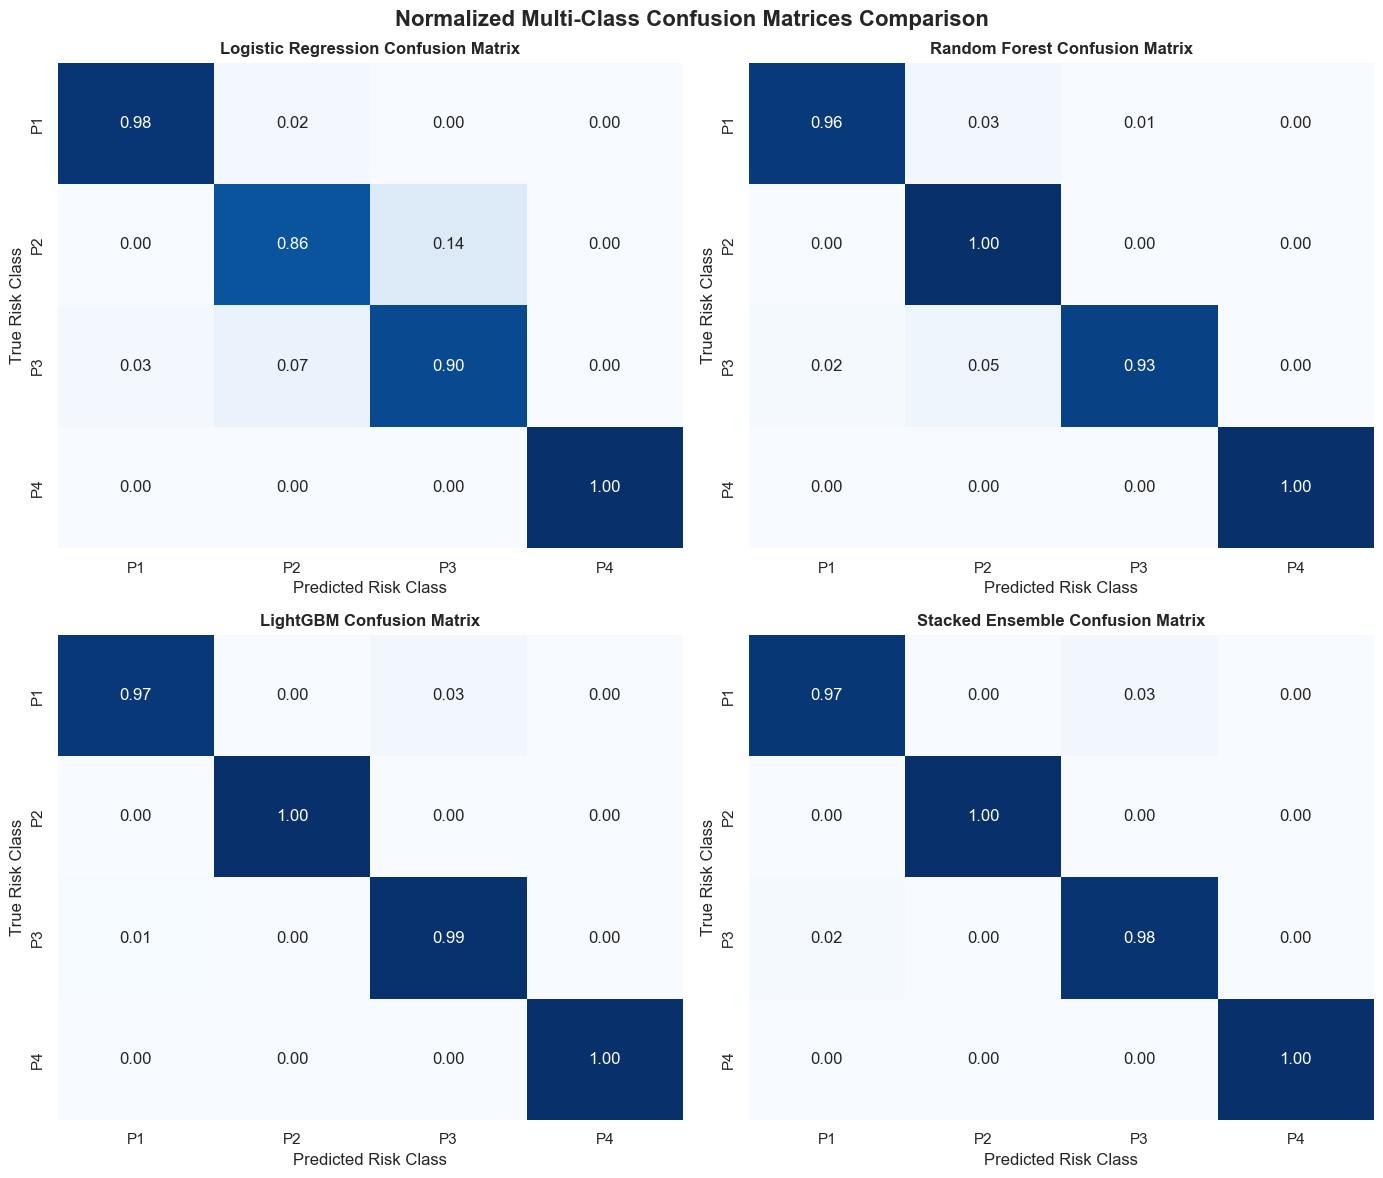

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

print("--- Starting Phase 7: Multi-Class Evaluation Framework ---")

# 1. Gather discrete predictions from individual Level-0 base learners
preds_lr = model_lr.predict(X_test_selected)
preds_rf = model_rf.predict(X_test_selected)
preds_lgb = model_lgb.predict(X_test_selected)
# 'ensemble_preds' was already computed in the previous step

model_predictions = {
    'Logistic Regression': preds_lr,
    'Random Forest': preds_rf,
    'LightGBM': preds_lgb,
    'Stacked Ensemble': ensemble_preds
}

# 2. Compute global metrics and per-class metrics
summary_data = []
per_class_f1_data = {}

for name, preds in model_predictions.items():
    # Calculate global metrics
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')
    
    # Calculate per-class F1-scores to track minority performance
    _, _, class_f1, _ = precision_recall_fscore_support(y_test, preds, average=None)
    per_class_f1_data[name] = class_f1
    
    summary_data.append({
        'Model Architecture': name,
        'Accuracy': acc,
        'Macro Precision': prec,
        'Macro Recall': rec,
        'Macro F1-Score': f1
    })

# 3. Display the Master Performance Comparison Table
comparison_df = pd.DataFrame(summary_data)
print("\n=== MASTER PERFORMANCE COMPARISON (OVERALL) ===")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 4. Display the Per-Class F1-Score Table
class_labels = ['P1 (Low Risk)', 'P2 (Med-Low)', 'P3 (Med-High)', 'P4 (High Risk)']
class_f1_df = pd.DataFrame(per_class_f1_data, index=class_labels).T
print("\n=== PER-CLASS F1-SCORE BREAKDOWN ===")
print(class_f1_df.to_string(float_format=lambda x: f"{x:.4f}"))

# 5. Generate and Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()
class_names = ['P1', 'P2', 'P3', 'P4']

for idx, (name, preds) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    # Normalize by rows (true values) to show percentage accuracy per cell
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=12, weight='bold')
    axes[idx].set_xlabel('Predicted Risk Class')
    axes[idx].set_ylabel('True Risk Class')

plt.suptitle('Normalized Multi-Class Confusion Matrices Comparison', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Generate and print performance tables

In [59]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("--- Phase 7: Generating Summary Dataframes ---")

preds_lr = model_lr.predict(X_test_selected)
preds_rf = model_rf.predict(X_test_selected)
preds_lgb = model_lgb.predict(X_test_selected)

model_predictions = {
    'Logistic Regression': preds_lr,
    'Random Forest': preds_rf,
    'LightGBM': preds_lgb,
    'Stacked Ensemble': ensemble_preds
}

summary_data = []
per_class_f1_data = {}

for name, preds in model_predictions.items():
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')
    _, _, class_f1, _ = precision_recall_fscore_support(y_test, preds, average=None)
    
    per_class_f1_data[name] = class_f1
    summary_data.append({
        'Model Architecture': name,
        'Accuracy': acc,
        'Macro Precision': prec,
        'Macro Recall': rec,
        'Macro F1-Score': f1
    })

comparison_df = pd.DataFrame(summary_data)
class_labels = ['P1 (Low Risk)', 'P2 (Med-Low)', 'P3 (Med-High)', 'P4 (High Risk)']
class_f1_df = pd.DataFrame(per_class_f1_data, index=class_labels).T

print("\n=== TABLE 1: MASTER PERFORMANCE COMPARISON ===")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n=== TABLE 2: PER-CLASS F1-SCORE BREAKDOWN ===")
print(class_f1_df.to_string(float_format=lambda x: f"{x:.4f}"))

--- Phase 7: Generating Summary Dataframes ---

=== TABLE 1: MASTER PERFORMANCE COMPARISON ===
 Model Architecture  Accuracy  Macro Precision  Macro Recall  Macro F1-Score
Logistic Regression    0.8966           0.8863        0.9352          0.9023
      Random Forest    0.9857           0.9886        0.9730          0.9805
           LightGBM    0.9946           0.9900        0.9888          0.9894
   Stacked Ensemble    0.9938           0.9879        0.9879          0.9879

=== TABLE 2: PER-CLASS F1-SCORE BREAKDOWN ===
                     P1 (Low Risk)  P2 (Med-Low)  P3 (Med-High)  P4 (High Risk)
Logistic Regression         0.9714        0.9157         0.7228          0.9994
Random Forest               0.9684        0.9912         0.9631          0.9994
LightGBM                    0.9762        1.0000         0.9816          0.9997
Stacked Ensemble            0.9735        0.9999         0.9786          0.9994


### Comparative Performance Metrics Chart

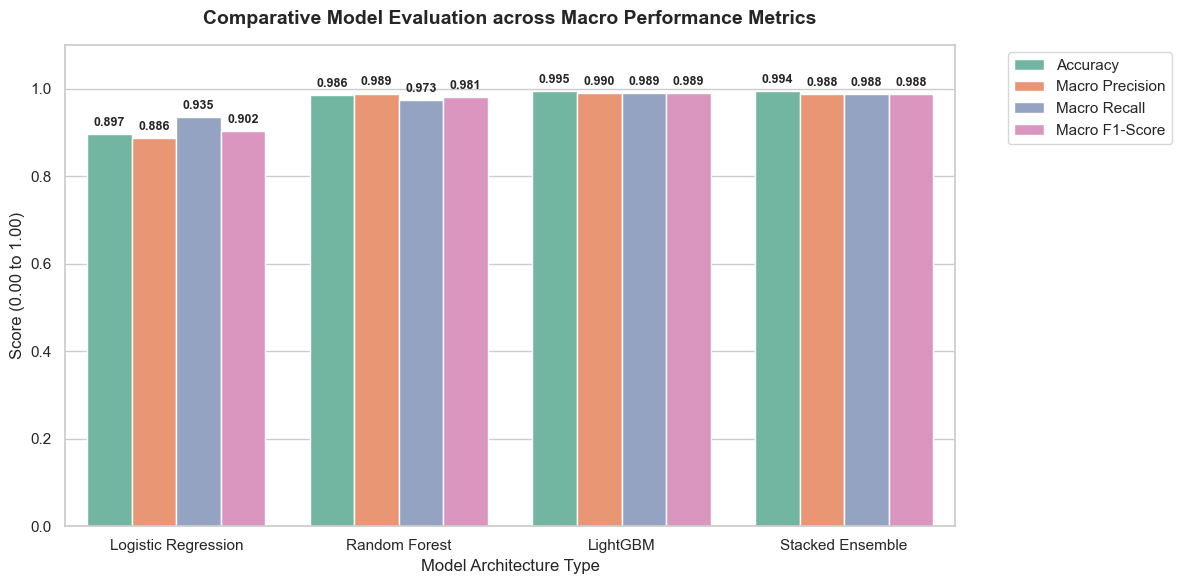

✔ Saved comparison graph as 'model_performance_comparison.png'


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the dataframe to make it compatible with seaborn's grouped bar charts
melted_df = pd.melt(comparison_df, id_vars=['Model Architecture'], 
                    value_vars=['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
                    var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x='Model Architecture', y='Score', hue='Metric', data=melted_df, palette='Set2')

# Annotate values on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                    ha='center', va='center', weight='bold', size=9, xytext=(0, 5),
                    textcoords='offset points')

plt.title('Comparative Model Evaluation across Macro Performance Metrics', fontsize=14, weight='bold', pad=15)
plt.ylabel('Score (0.00 to 1.00)', fontsize=12)
plt.xlabel('Model Architecture Type', fontsize=12)
plt.ylim(0, 1.1)  # Headroom for labels
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save image cleanly
plt.savefig('model_performance_comparison.png', dpi=300)
plt.show()
print("✔ Saved comparison graph as 'model_performance_comparison.png'")

### Isolated Confusion Matrix Generator

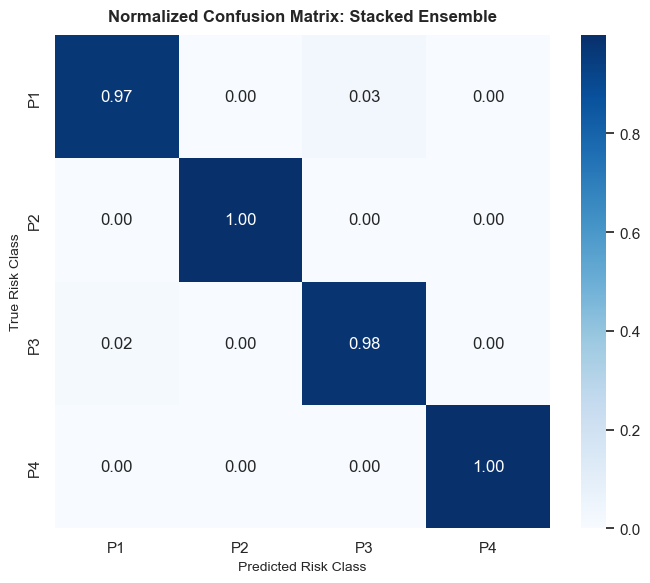

✔ Isolated image generated and saved as 'stacked_ensemble_confusion_matrix.png'


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Change this string to 'Logistic Regression', 'Random Forest', 'LightGBM', or 'Stacked Ensemble'
model_to_plot = 'Stacked Ensemble' 

preds = model_predictions[model_to_plot]
cm = confusion_matrix(y_test, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize rows

plt.figure(figsize=(7, 6))
class_names = ['P1', 'P2', 'P3', 'P4']

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=True)

plt.title(f'Normalized Confusion Matrix: {model_to_plot}', fontsize=12, weight='bold', pad=10)
plt.xlabel('Predicted Risk Class', fontsize=10)
plt.ylabel('True Risk Class', fontsize=10)
plt.tight_layout()

# Save the figure dynamically using the model's name
file_name = f"{model_to_plot.lower().replace(' ', '_')}_confusion_matrix.png"
plt.savefig(file_name, dpi=300)
plt.show()
print(f"✔ Isolated image generated and saved as '{file_name}'")

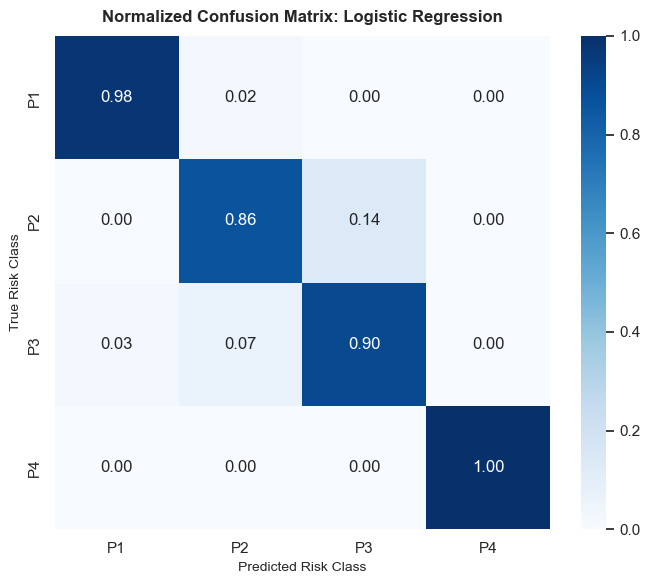

✔ Isolated image generated and saved as 'logistic_regression_confusion_matrix.png'


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Change this string to 'Logistic Regression', 'Random Forest', 'LightGBM', or 'Stacked Ensemble'
model_to_plot = 'Logistic Regression' 

preds = model_predictions[model_to_plot]
cm = confusion_matrix(y_test, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize rows

plt.figure(figsize=(7, 6))
class_names = ['P1', 'P2', 'P3', 'P4']

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=True)

plt.title(f'Normalized Confusion Matrix: {model_to_plot}', fontsize=12, weight='bold', pad=10)
plt.xlabel('Predicted Risk Class', fontsize=10)
plt.ylabel('True Risk Class', fontsize=10)
plt.tight_layout()

# Save the figure dynamically using the model's name
file_name = f"{model_to_plot.lower().replace(' ', '_')}_confusion_matrix.png"
plt.savefig(file_name, dpi=300)
plt.show()
print(f"✔ Isolated image generated and saved as '{file_name}'")

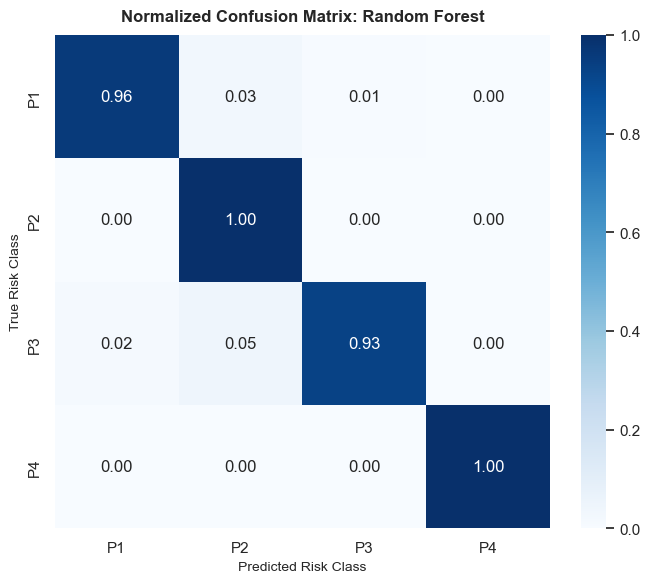

✔ Isolated image generated and saved as 'random_forest_confusion_matrix.png'


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Change this string to 'Logistic Regression', 'Random Forest', 'LightGBM', or 'Stacked Ensemble'
model_to_plot = 'Random Forest' 

preds = model_predictions[model_to_plot]
cm = confusion_matrix(y_test, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize rows

plt.figure(figsize=(7, 6))
class_names = ['P1', 'P2', 'P3', 'P4']

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=True)

plt.title(f'Normalized Confusion Matrix: {model_to_plot}', fontsize=12, weight='bold', pad=10)
plt.xlabel('Predicted Risk Class', fontsize=10)
plt.ylabel('True Risk Class', fontsize=10)
plt.tight_layout()

# Save the figure dynamically using the model's name
file_name = f"{model_to_plot.lower().replace(' ', '_')}_confusion_matrix.png"
plt.savefig(file_name, dpi=300)
plt.show()
print(f"✔ Isolated image generated and saved as '{file_name}'")

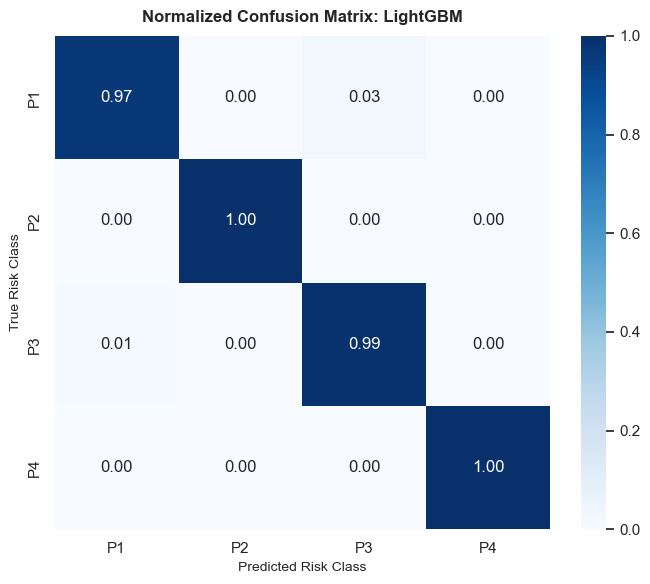

✔ Isolated image generated and saved as 'lightgbm_confusion_matrix.png'


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Change this string to 'Logistic Regression', 'Random Forest', 'LightGBM', or 'Stacked Ensemble'
model_to_plot = 'LightGBM' 

preds = model_predictions[model_to_plot]
cm = confusion_matrix(y_test, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize rows

plt.figure(figsize=(7, 6))
class_names = ['P1', 'P2', 'P3', 'P4']

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=True)

plt.title(f'Normalized Confusion Matrix: {model_to_plot}', fontsize=12, weight='bold', pad=10)
plt.xlabel('Predicted Risk Class', fontsize=10)
plt.ylabel('True Risk Class', fontsize=10)
plt.tight_layout()

# Save the figure dynamically using the model's name
file_name = f"{model_to_plot.lower().replace(' ', '_')}_confusion_matrix.png"
plt.savefig(file_name, dpi=300)
plt.show()
print(f"✔ Isolated image generated and saved as '{file_name}'")

## For Web App - Serialize and Save Model Objects

In [74]:
import pickle

print("--- Packaging Pipeline Artifacts for Web App ---")

# Pack everything needed for runtime inference into a single state dictionary
app_artifacts = {
    'selected_features': top_features,   # The 35 optimized features from Phase 5
    'scaler': scaler,                     # The mathematical StandardScaler from Phase 3
    'label_encoder': le,                  # Binary label encoder instance
    'base_model_lr': model_lr,            # Base Linear Learner
    'base_model_rf': model_rf,            # Base Bagging Learner
    'base_model_lgb': model_lgb,          # Base Boosting Learner
    'meta_learner': meta_learner          # Final Level-1 Stacking Classifier
}

# Write binary file to disk
with open('stacked_ensemble_risk_pipeline.pkl', 'wb') as f:
    pickle.dump(app_artifacts, f)

print("✔ Pipeline successfully serialized to 'stacked_ensemble_risk_pipeline.pkl'!")

--- Packaging Pipeline Artifacts for Web App ---
✔ Pipeline successfully serialized to 'stacked_ensemble_risk_pipeline.pkl'!


In [1]:
print("--- Exporting Raw Test Samples for App Integration ---")

# Grab the same indices from our master_df that ended up in the test set
X_test_raw_view = master_df.loc[X_test.index].copy()

# Add the true labels back so we can see what the actual credit outcome was
X_test_raw_view['True_Approved_Flag'] = y_test.map({0:'P1', 1:'P2', 2:'P3', 3:'P4'})

# Save a clean batch of 100 sample records to a CSV file
X_test_raw_view.head(100).to_csv('app_test_samples.csv', index=True)
print("✔ Saved 'app_test_samples.csv' to your project folder!")

--- Exporting Raw Test Samples for App Integration ---


NameError: name 'master_df' is not defined